In [1]:
import pandas as pd
import matplotlib.pyplot as plt
#from ydata_profiling import ProfileReport
import seaborn as sns
import numpy as np
from imblearn.over_sampling import SMOTE
from collections import Counter
import copy
from optuna.samplers import TPESampler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, accuracy_score
from sklearn.model_selection import cross_val_score, KFold, cross_validate
#import optuna
#from optuna.samplers import TPESampler
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
from sklearn.ensemble import AdaBoostClassifier
import xgboost as xgb
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
from sklearn.exceptions import ConvergenceWarning
import optuna
warnings.filterwarnings("ignore")


%matplotlib inline

In [2]:
# Import the functions from the prep_functions notebook
%run "./02_prep_functions.ipynb"

# Check if the main functions and variables are imported correctly
print("Function imported correctly:")
print(f"- preprocess_train_df: {preprocess_train_df.__name__}")
print(f"- preprocess_test_df: {preprocess_test_df.__name__}")
print(f"- split_sets: {split_sets.__name__}")

Function imported correctly:
- preprocess_train_df: preprocess_train_df
- preprocess_test_df: preprocess_test_df
- split_sets: split_sets


In [3]:
# Reading CSV files with pandas

cancer_df = pd.read_csv('https://raw.githubusercontent.com/gascalero/DM_II_project/4a73ca4928f2b95f960cd9b9f44c4700244ed553/data/raw/patient_train_data.csv',
                        encoding='UTF-8',
                        index_col=0,
                        sep=',',
                        on_bad_lines='skip',
                        quoting=3)
cancer_df.head(1)

# Splitting the dataset into training and validation sets
X_train, X_val, y_train, y_val = split_sets(cancer_df)

# Running the preprocessing pipeline for the training set
X_train_processed, y_train_processed, mode_train, stats_pre, encoders = preprocess_train_df(X_train, y_train, columns_to_delete, values_to_imput_cat, binary_cols, ordinal_mappings, numeric_cols, categorical_cols)

# Running the preprocessing pipeline for the validation set

X_val_processed = preprocess_test_df(X_val, X_train_processed.columns, values_to_imput_cat, columns_to_delete, mode_train, stats_pre, binary_cols, numeric_cols, categorical_cols, encoders)

# y_val_processed = y_val.copy() for following the same convention as X_val_processed
y_val_processed = y_val.copy()

Dimension of X_train: (60028, 30)
Dimension of X_test: (15007, 30)
Dimension of y_train: (60028,)
Dimension of y_test: (15007,)
Dimension of train set before preprocessing: (60028, 34)
Dimension of train set after preprocessing: (59180, 48)
Dimension of test set before preprocessing: (15007, 34)
Dimension of test set after preprocessing: (15007, 48)


In [4]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# SBS FEATURES

## LOGISTIC REGRESSION

In [5]:
selected_features = ['Country_Nigeria', 'Country_Pakistan', 'Country_South Africa',
                     'Country_South Korea', 'Country_UK', 'Country_USA',
                     'Insurance Costs_Extended', 'Insurance Costs_No insurance',
                     'Treatment Type_Combination', 'Treatment Type_Radiotherapy',
                     'Treatment Type_Surgery', 'Hypertension_Yes', 'Insurance Status_Uninsured',
                     'Non Smoker_Yes', 'Urban or Rural_Urban']
X_train_reduced = X_train_processed[selected_features].copy()
X_val_reduced = X_val_processed[selected_features].copy()

[I 2025-05-10 20:56:16,822] A new study created in memory with name: no-name-ac624c2f-7562-4f1a-90d7-0926cb375377


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-05-10 20:56:19,451] Trial 0 finished with value: 0.30285499293487084 and parameters: {'C': 0.004185822729546971, 'solver': 'saga', 'max_iter': 8927, 'penalty': 'l1'}. Best is trial 0 with value: 0.30285499293487084.

Trial 0 completado.
Valor: 0.3029
Parámetros: {'C': 0.004185822729546971, 'solver': 'saga', 'max_iter': 8927, 'penalty': 'l1'}
Std F1: 0.03528287698574117
[I 2025-05-10 20:56:23,217] Trial 1 finished with value: 0.4944619363155738 and parameters: {'C': 0.000123631882770522, 'solver': 'saga', 'max_iter': 1432, 'penalty': 'l2'}. Best is trial 1 with value: 0.4944619363155738.

Trial 1 completado.
Valor: 0.4945
Parámetros: {'C': 0.000123631882770522, 'solver': 'saga', 'max_iter': 1432, 'penalty': 'l2'}
Std F1: 0.003939558710122948
[I 2025-05-10 20:56:26,984] Trial 2 finished with value: 0.49526262428470746 and parameters: {'C': 0.16136341713591323, 'solver': 'saga', 'max_iter': 5105, 'penalty': 'l2'}. Best is trial 2 with value: 0.49526262428470746.

Trial 2 completad

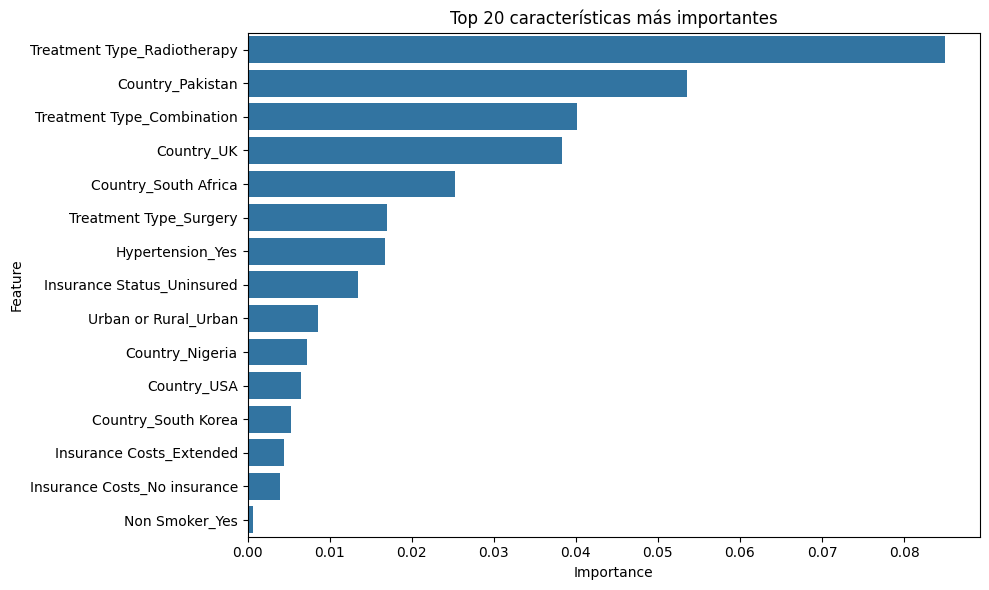

In [26]:
def objective(trial):
    # Definir el espacio de búsqueda para los hiperparámetros
    C = trial.suggest_float('C', 1e-5, 100, log=True)
    solver = trial.suggest_categorical('solver', ['saga'])
    max_iter = trial.suggest_int('max_iter', 1000, 10000, log=True)
    
    # Para los solvers que soportan regularización
    if solver in ['saga']:
        penalty = trial.suggest_categorical('penalty', ['l1', 'l2'])
        # saga es el único que soporta elasticnet
        if solver == 'saga':
            if penalty == 'elasticnet':
                l1_ratio = trial.suggest_float('l1_ratio', 0.0, 1.0)
            else:
                l1_ratio = None
        else:
            l1_ratio = None
    else:  # lbfgs solo soporta l2
        penalty = 'l2'
        l1_ratio = None
    
    # Configurar el modelo de regresión logística
    if penalty == 'elasticnet' and solver == 'saga':
        model = LogisticRegression(
            C=C, 
            penalty=penalty,
            solver=solver,
            max_iter=max_iter,
            l1_ratio=l1_ratio,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        )
    else:
        model = LogisticRegression(
            C=C, 
            penalty=penalty,
            solver=solver,
            max_iter=max_iter,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        )
    
    # Realizar validación cruzada
    cv_scores = []
    
    for train_idx, val_idx in kf.split(X_train_reduced, y_train_processed):
        X_train_fold, X_val_fold = X_train_reduced.iloc[train_idx], X_train_reduced.iloc[val_idx]
        y_train_fold, y_val_fold = y_train_processed.iloc[train_idx], y_train_processed.iloc[val_idx]
        
        try:
            model.fit(X_train_fold, y_train_fold)
            y_pred = model.predict(X_val_fold)
            fold_score = f1_score(y_val_fold, y_pred, average='macro')
            cv_scores.append(fold_score)
        except Exception as e:
            # Si hay error en un fold, retornar un valor muy bajo
            print(f"Error en fold: {str(e)}")
            return float('-inf')
    
    # Calcular la media del F1 score en todos los folds
    mean_f1 = np.mean(cv_scores)
    
    # Guardar métricas adicionales como atributos del trial
    trial.set_user_attr('cv_scores', cv_scores)
    trial.set_user_attr('std_f1', np.std(cv_scores))
    
    return mean_f1

def optimize_logistic_regression():
    # Crear el objeto de estudio
    study = optuna.create_study(
        direction="maximize",
        sampler=TPESampler(seed=42),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=5)
    )
    
    # Definir callback para mostrar progreso
    def print_callback(study, trial):
        print(f"\nTrial {trial.number} completado.")
        print(f"Valor: {trial.value:.4f}")
        print(f"Parámetros: {trial.params}")
        if trial.user_attrs:
            print(f"Std F1: {trial.user_attrs.get('std_f1', 'N/A')}")
    
    # Ejecutar la optimización
    study.optimize(objective, n_trials=50, callbacks=[print_callback], show_progress_bar=True)
    
    # Mostrar los mejores resultados
    print("\n" + "="*50)
    print("MEJORES HIPERPARÁMETROS ENCONTRADOS:")
    print("="*50)
    
    best_trial = study.best_trial
    print(f"Mejor F1 Macro: {best_trial.value:.4f}")
    print(f"Desviación estándar: {best_trial.user_attrs.get('std_f1', 'N/A'):.4f}")
    print("\nHiperparámetros óptimos:")
    
    for param, value in best_trial.params.items():
        print(f"    {param}: {value}")
    
    # Crear y entrenar el modelo final con los mejores hiperparámetros
    best_params = best_trial.params.copy()
    
    # Manejar parámetros opcionales
    if 'l1_ratio' in best_params and best_params.get('penalty') != 'elasticnet':
        del best_params['l1_ratio']
    
    # Crear el modelo final
    if best_params.get('penalty') == 'elasticnet' and best_params.get('solver') == 'saga':
        best_model = LogisticRegression(
            **best_params,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        )
    else:
        # Eliminar l1_ratio si existe y no es necesario
        if 'l1_ratio' in best_params:
            del best_params['l1_ratio']
        best_model = LogisticRegression(
            **best_params,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        )
    
    # Entrenar con todo el conjunto de entrenamiento
    best_model.fit(X_train_reduced, y_train_processed)
    
    # Evaluar en el conjunto de validación
    y_pred = best_model.predict(X_val_reduced)
    val_f1 = f1_score(y_val_processed, y_pred, average='macro')
    
    print("\nRendimiento en el conjunto de validación:")
    print(f"F1 Macro: {val_f1:.4f}")
    
    # Visualizar la importancia de las características
    if hasattr(best_model, 'coef_'):
        # Ensure the number of features matches the coefficients
        if len(X_train_reduced.columns) == len(best_model.coef_[0]):
            feature_importance = pd.DataFrame({
                'Feature': X_train_reduced.columns,
                'Importance': np.abs(best_model.coef_[0])
            }).sort_values('Importance', ascending=False)
        else:
            print("Warning: Mismatch between feature names and model coefficients.")
            feature_importance = pd.DataFrame({
                'Feature': X_train_reduced.columns[:len(best_model.coef_[0])],
                'Importance': np.abs(best_model.coef_[0])
            }).sort_values('Importance', ascending=False)
        
        plt.figure(figsize=(10, 6))
        sns.barplot(x='Importance', y='Feature', data=feature_importance.head(20))
        plt.title('Top 20 características más importantes')
        plt.tight_layout()
        plt.show()
    
    return best_model, study

# Ejecutar la optimización
best_lr_model, lr_study = optimize_logistic_regression()

## RANDOM FOREST

[I 2025-05-10 21:08:39,759] A new study created in memory with name: no-name-72ae18db-6721-421d-a210-75686247f90a


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-05-10 21:09:08,971] Trial 0 finished with value: 0.4992025331849533 and parameters: {'n_estimators': 218, 'max_depth': 29, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 0 with value: 0.4992025331849533.

Trial 0 completado.
Valor original: 0.4992
Valor ajustado: 0.4992
Parámetros: {'n_estimators': 218, 'max_depth': 29, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'bootstrap': True}
Std F1: 0.004152473307985305
Sobreajuste: 0.0452
[I 2025-05-10 21:09:28,802] Trial 1 finished with value: 0.4981217762189164 and parameters: {'n_estimators': 369, 'max_depth': 5, 'min_samples_split': 20, 'min_samples_leaf': 9, 'max_features': 'sqrt', 'bootstrap': False}. Best is trial 0 with value: 0.4992025331849533.

Trial 1 completado.
Valor original: 0.4981
Valor ajustado: 0.4981
Parámetros: {'n_estimators': 369, 'max_depth': 5, 'min_samples_split': 20, 'min_samples_leaf': 9, 'max_features': 'sqrt', 'bootstrap'

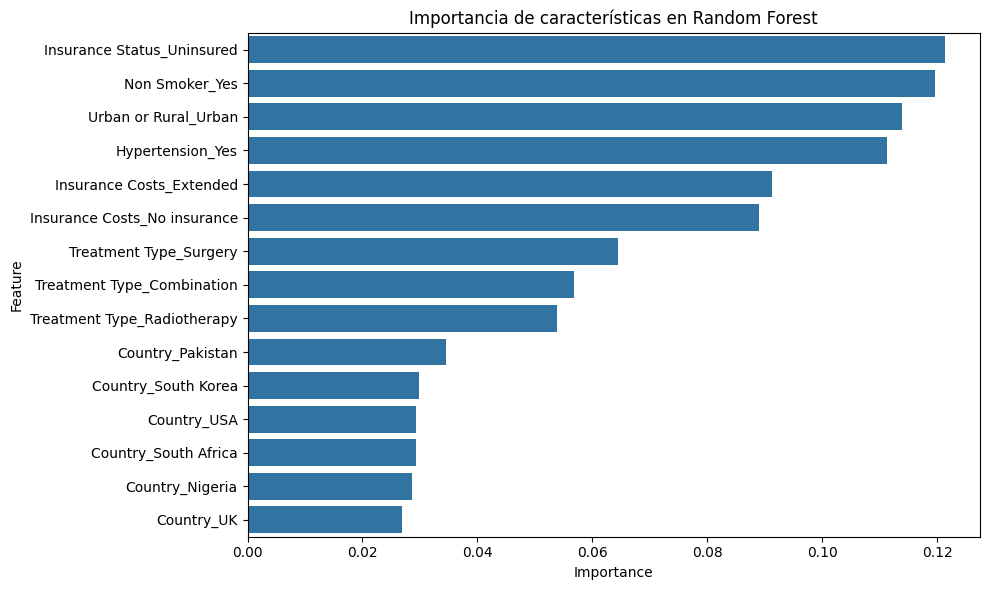

In [27]:
def rf_objective(trial):
    # Definir el espacio de búsqueda para los hiperparámetros
    n_estimators = trial.suggest_int('n_estimators', 50, 500)
    max_depth = trial.suggest_int('max_depth', 5, 30)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
    bootstrap = trial.suggest_categorical('bootstrap', [True, False])
    
    # Configurar el modelo RandomForest
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        bootstrap=bootstrap,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
    
    # Realizar validación cruzada
    cv_scores = []
    
    for train_idx, val_idx in kf.split(X_train_reduced, y_train_processed):
        X_train_fold, X_val_fold = X_train_reduced.iloc[train_idx], X_train_reduced.iloc[val_idx]
        y_train_fold, y_val_fold = y_train_processed.iloc[train_idx], y_train_processed.iloc[val_idx]
        
        try:
            model.fit(X_train_fold, y_train_fold)
            
            # Calcular predicciones y F1 score
            y_pred = model.predict(X_val_fold)
            fold_score = f1_score(y_val_fold, y_pred, average='macro')
            
            # Calcular overfitting: diferencia entre train y val
            y_train_pred = model.predict(X_train_fold)
            train_score = f1_score(y_train_fold, y_train_pred, average='macro')
            overfit = train_score - fold_score
            
            cv_scores.append(fold_score)
            
            # Almacenar métricas adicionales
            trial.set_user_attr(f'train_f1_fold_{len(cv_scores)}', train_score)
            trial.set_user_attr(f'val_f1_fold_{len(cv_scores)}', fold_score)
            trial.set_user_attr(f'overfit_fold_{len(cv_scores)}', overfit)
            
        except Exception as e:
            # Si hay error en un fold, retornar un valor muy bajo
            print(f"Error en fold: {str(e)}")
            return float('-inf')
    
    # Calcular la media del F1 score en todos los folds
    mean_f1 = np.mean(cv_scores)
    
    # Calcular métricas agregadas
    train_scores = [trial.user_attrs[f'train_f1_fold_{i+1}'] for i in range(len(cv_scores))]
    val_scores = [trial.user_attrs[f'val_f1_fold_{i+1}'] for i in range(len(cv_scores))]
    overfit_scores = [trial.user_attrs[f'overfit_fold_{i+1}'] for i in range(len(cv_scores))]
    
    # Guardar métricas adicionales como atributos del trial
    trial.set_user_attr('cv_scores', cv_scores)
    trial.set_user_attr('std_f1', np.std(cv_scores))
    trial.set_user_attr('mean_train_f1', np.mean(train_scores))
    trial.set_user_attr('mean_overfit', np.mean(overfit_scores))
    
    # Penalización por sobreajuste para guiar la búsqueda hacia modelos más generalizables
    if np.mean(overfit_scores) > 0.1:  # Si hay sobreajuste significativo
        penalty = (np.mean(overfit_scores) - 0.1) * 0.5  # Penalización proporcional al exceso de sobreajuste
        adjusted_score = mean_f1 - penalty
    else:
        adjusted_score = mean_f1
    
    trial.set_user_attr('adjusted_score', adjusted_score)
    
    return adjusted_score  # Retornamos el score ajustado para guiar la optimización

def optimize_random_forest():
    # Crear el objeto de estudio
    study = optuna.create_study(
        direction="maximize",
        sampler=TPESampler(seed=42),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=5)
    )
    
    # Definir callback para mostrar progreso
    def print_callback(study, trial):
        print(f"\nTrial {trial.number} completado.")
        print(f"Valor original: {np.mean(trial.user_attrs.get('cv_scores', [0])):.4f}")
        print(f"Valor ajustado: {trial.value:.4f}")
        print(f"Parámetros: {trial.params}")
        print(f"Std F1: {trial.user_attrs.get('std_f1', 'N/A')}")
        print(f"Sobreajuste: {trial.user_attrs.get('mean_overfit', 'N/A'):.4f}")
    
    # Ejecutar la optimización
    study.optimize(rf_objective, n_trials=50, callbacks=[print_callback], show_progress_bar=True)
    
    # Mostrar los mejores resultados
    print("\n" + "="*50)
    print("MEJORES HIPERPARÁMETROS ENCONTRADOS PARA RANDOM FOREST:")
    print("="*50)
    
    best_trial = study.best_trial
    print(f"Mejor F1 Macro ajustado: {best_trial.value:.4f}")
    print(f"Mejor F1 Macro original: {np.mean(best_trial.user_attrs.get('cv_scores', [0])):.4f}")
    print(f"Desviación estándar: {best_trial.user_attrs.get('std_f1', 'N/A'):.4f}")
    print(f"Sobreajuste: {best_trial.user_attrs.get('mean_overfit', 'N/A'):.4f}")
    print("\nHiperparámetros óptimos:")
    
    for param, value in best_trial.params.items():
        print(f"    {param}: {value}")
    
    # Crear y entrenar el modelo final con los mejores hiperparámetros
    best_params = best_trial.params.copy()
    best_model = RandomForestClassifier(
        **best_params,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
    
    # Entrenar con todo el conjunto de entrenamiento
    best_model.fit(X_train_reduced, y_train_processed)
    
    # Evaluar en el conjunto de validación
    y_pred = best_model.predict(X_val_reduced)
    val_f1 = f1_score(y_val_processed, y_pred, average='macro')
    
    print("\nRendimiento en el conjunto de validación:")
    print(f"F1 Macro: {val_f1:.4f}")
    
    # Visualizar la importancia de las características
    feature_importance = pd.DataFrame({
        'Feature': X_train_reduced.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_importance)
    plt.title('Importancia de características en Random Forest')
    plt.tight_layout()
    plt.show()
    
    return best_model, study

# Ejecutar la optimización
best_rf_model, rf_study = optimize_random_forest()

## ADABOOST

In [7]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import f1_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from optuna.samplers import TPESampler

def adaboost_objective(trial):
    # Definir el espacio de búsqueda para los hiperparámetros
    n_estimators = trial.suggest_int('n_estimators', 50, 500)
    learning_rate = trial.suggest_float('learning_rate', 0.001, 0.5, log=True)
    algorithm = trial.suggest_categorical('algorithm', ['SAMME', 'SAMME.R'])
    
    # Parámetros para el clasificador base (DecisionTreeClassifier)
    base_max_depth = trial.suggest_int('base_max_depth', 1, 5)
    base_min_samples_split = trial.suggest_int('base_min_samples_split', 2, 10)
    
    # Configurar el clasificador base
    base_estimator = DecisionTreeClassifier(
        max_depth=base_max_depth,
        min_samples_split=base_min_samples_split,
        class_weight='balanced',
        random_state=42
    )
    
    # Configurar el modelo AdaBoost
    model = AdaBoostClassifier(
        estimator=base_estimator,
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        algorithm=algorithm,
        random_state=42
    )
    
    # Realizar validación cruzada
    cv_scores = []
    f1_class0_scores = []  # Específicamente para monitorear f1 en clase 0
    recall_class0_scores = []  # Específicamente para monitorear recall en clase 0
    
    for train_idx, val_idx in kf.split(X_train_reduced, y_train_processed):
        X_train_fold, X_val_fold = X_train_reduced.iloc[train_idx], X_train_reduced.iloc[val_idx]
        y_train_fold, y_val_fold = y_train_processed.iloc[train_idx], y_train_processed.iloc[val_idx]
        
        try:
            model.fit(X_train_fold, y_train_fold)
            
            # Calcular predicciones y F1 score
            y_pred = model.predict(X_val_fold)
            fold_score = f1_score(y_val_fold, y_pred, average='macro')
            
            # Calcular métricas específicas para clase 0 (no sobrevivientes)
            f1_class0 = f1_score(y_val_fold, y_pred, average=None)[0]
            
            # Calcular recall específico para clase 0
            from sklearn.metrics import recall_score
            recall_class0 = recall_score(y_val_fold, y_pred, average=None)[0]
            
            # Calcular overfitting
            y_train_pred = model.predict(X_train_fold)
            train_score = f1_score(y_train_fold, y_train_pred, average='macro')
            overfit = train_score - fold_score
            
            cv_scores.append(fold_score)
            f1_class0_scores.append(f1_class0)
            recall_class0_scores.append(recall_class0)
            
            # Almacenar métricas adicionales
            trial.set_user_attr(f'train_f1_fold_{len(cv_scores)}', train_score)
            trial.set_user_attr(f'val_f1_fold_{len(cv_scores)}', fold_score)
            trial.set_user_attr(f'overfit_fold_{len(cv_scores)}', overfit)
            trial.set_user_attr(f'f1_class0_fold_{len(cv_scores)}', f1_class0)
            trial.set_user_attr(f'recall_class0_fold_{len(cv_scores)}', recall_class0)
            
        except Exception as e:
            # Si hay error en un fold, retornar un valor muy bajo
            print(f"Error en fold: {str(e)}")
            return float('-inf')
    
    # Calcular las medias de las métricas en todos los folds
    mean_f1 = np.mean(cv_scores)
    mean_f1_class0 = np.mean(f1_class0_scores)
    mean_recall_class0 = np.mean(recall_class0_scores)
    
    # Calcular métricas agregadas
    train_scores = [trial.user_attrs[f'train_f1_fold_{i+1}'] for i in range(len(cv_scores))]
    overfit_scores = [trial.user_attrs[f'overfit_fold_{i+1}'] for i in range(len(cv_scores))]
    
    # Guardar métricas adicionales como atributos del trial
    trial.set_user_attr('cv_scores', cv_scores)
    trial.set_user_attr('std_f1', np.std(cv_scores))
    trial.set_user_attr('mean_train_f1', np.mean(train_scores))
    trial.set_user_attr('mean_overfit', np.mean(overfit_scores))
    trial.set_user_attr('mean_f1_class0', mean_f1_class0)
    trial.set_user_attr('mean_recall_class0', mean_recall_class0)
    
    # Aplicar una función de objetivo personalizada que priorice el recall de clase 0
    # mientras mantiene un buen F1 macro general
    # Damos un peso extra al recall de clase 0 para minimizar falsos positivos
    custom_score = 0.6 * mean_f1 + 0.4 * mean_recall_class0
    
    # Penalización por sobreajuste para guiar la búsqueda hacia modelos más generalizables
    if np.mean(overfit_scores) > 0.1:
        penalty = (np.mean(overfit_scores) - 0.1) * 0.5
        adjusted_score = custom_score - penalty
    else:
        adjusted_score = custom_score
    
    trial.set_user_attr('custom_score', custom_score)
    trial.set_user_attr('adjusted_score', adjusted_score)
    
    return adjusted_score

def optimize_adaboost():
    # Crear el objeto de estudio
    study = optuna.create_study(
        direction="maximize",
        sampler=TPESampler(seed=42),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=5)
    )
    
    # Definir callback para mostrar progreso
    def print_callback(study, trial):
        print(f"\nTrial {trial.number} completado.")
        print(f"Valor original (F1 macro): {np.mean(trial.user_attrs.get('cv_scores', [0])):.4f}")
        
        # Safely format F1 clase 0
        mean_f1_class0 = trial.user_attrs.get('mean_f1_class0', 'N/A')
        if isinstance(mean_f1_class0, (int, float)):
            print(f"F1 clase 0: {mean_f1_class0:.4f}")
        else:
            print(f"F1 clase 0: {mean_f1_class0}")
        
        # Safely format Recall clase 0
        mean_recall_class0 = trial.user_attrs.get('mean_recall_class0', 'N/A')
        if isinstance(mean_recall_class0, (int, float)):
            print(f"Recall clase 0: {mean_recall_class0:.4f}")
        else:
            print(f"Recall clase 0: {mean_recall_class0}")
        
        # Safely format Valor ajustado
        if isinstance(trial.value, (int, float)):
            print(f"Valor ajustado: {trial.value:.4f}")
        else:
            print(f"Valor ajustado: {trial.value}")
        
        print(f"Parámetros: {trial.params}")
        
        # Safely format Std F1
        std_f1 = trial.user_attrs.get('std_f1', 'N/A')
        if isinstance(std_f1, (int, float)):
            print(f"Std F1: {std_f1:.4f}")
        else:
            print(f"Std F1: {std_f1}")
        
        # Safely format Sobreajuste
        mean_overfit = trial.user_attrs.get('mean_overfit', 'N/A')
        if isinstance(mean_overfit, (int, float)):
            print(f"Sobreajuste: {mean_overfit:.4f}")
        else:
            print(f"Sobreajuste: {mean_overfit}")
    
    # Ejecutar la optimización
    study.optimize(adaboost_objective, n_trials=50, callbacks=[print_callback], show_progress_bar=True)
    
    # Mostrar los mejores resultados
    print("\n" + "="*50)
    print("MEJORES HIPERPARÁMETROS ENCONTRADOS PARA ADABOOST:")
    print("="*50)
    
    best_trial = study.best_trial
    print(f"Mejor score ajustado: {best_trial.value:.4f}")
    print(f"Mejor F1 Macro original: {np.mean(best_trial.user_attrs.get('cv_scores', [0])):.4f}")
    print(f"Mejor F1 clase 0: {best_trial.user_attrs.get('mean_f1_class0', 'N/A'):.4f}")
    print(f"Mejor Recall clase 0: {best_trial.user_attrs.get('mean_recall_class0', 'N/A'):.4f}")
    print(f"Desviación estándar: {best_trial.user_attrs.get('std_f1', 'N/A'):.4f}")
    print(f"Sobreajuste: {best_trial.user_attrs.get('mean_overfit', 'N/A'):.4f}")
    print("\nHiperparámetros óptimos:")
    
    for param, value in best_trial.params.items():
        print(f"    {param}: {value}")
    
    # Crear y entrenar el modelo final con los mejores hiperparámetros
    base_estimator = DecisionTreeClassifier(
        max_depth=best_trial.params['base_max_depth'],
        min_samples_split=best_trial.params['base_min_samples_split'],
        class_weight='balanced',
        random_state=42
    )
    
    best_model = AdaBoostClassifier(
        estimator=base_estimator,
        n_estimators=best_trial.params['n_estimators'],
        learning_rate=best_trial.params['learning_rate'],
        algorithm=best_trial.params['algorithm'],
        random_state=42
    )
    
    # Entrenar con todo el conjunto de entrenamiento
    best_model.fit(X_train_reduced, y_train_processed)
    
    # Evaluar en el conjunto de validación
    y_pred = best_model.predict(X_val_reduced)
    val_f1 = f1_score(y_val_processed, y_pred, average='macro')
    val_f1_class0 = f1_score(y_val_processed, y_pred, average=None)[0]
    val_recall_class0 = recall_score(y_val_processed, y_pred, average=None)[0]
    
    print("\nRendimiento en el conjunto de validación:")
    print(f"F1 Macro: {val_f1:.4f}")
    print(f"F1 clase 0: {val_f1_class0:.4f}")
    print(f"Recall clase 0: {val_recall_class0:.4f}")
    
    # Visualizar la importancia de las características
    feature_importance = pd.DataFrame({
        'Feature': X_train_reduced.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_importance)
    plt.title('Importancia de características en AdaBoost')
    plt.tight_layout()
    plt.show()
    
    # Mostrar reporte de clasificación completo
    from sklearn.metrics import classification_report
    print("\nReporte de clasificación completo:")
    print(classification_report(y_val_processed, y_pred))
    
    return best_model, study

# Ejecutar la optimización
best_adaboost_model, adaboost_study = optimize_adaboost()

[I 2025-05-13 14:26:51,248] A new study created in memory with name: no-name-309baa72-c849-40c5-851f-3ca263995a53


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-05-13 14:26:51,768] Trial 0 finished with value: 0.3090218918862084 and parameters: {'n_estimators': 218, 'learning_rate': 0.36808608148776095, 'algorithm': 'SAMME', 'base_max_depth': 1, 'base_min_samples_split': 3}. Best is trial 0 with value: 0.3090218918862084.

Trial 0 completado.
Valor original (F1 macro): 0.4449
F1 clase 0: 0.1680
Recall clase 0: 0.1053
Valor ajustado: 0.3090
Parámetros: {'n_estimators': 218, 'learning_rate': 0.36808608148776095, 'algorithm': 'SAMME', 'base_max_depth': 1, 'base_min_samples_split': 3}
Std F1: 0.0023
Sobreajuste: 0.0000
[I 2025-05-13 14:27:10,831] Trial 1 finished with value: 0.46322794236337295 and parameters: {'n_estimators': 76, 'learning_rate': 0.21766241123453672, 'algorithm': 'SAMME.R', 'base_max_depth': 1, 'base_min_samples_split': 10}. Best is trial 1 with value: 0.46322794236337295.

Trial 1 completado.
Valor original (F1 macro): 0.4976
F1 clase 0: 0.4032
Recall clase 0: 0.4116
Valor ajustado: 0.4632
Parámetros: {'n_estimators': 76

NameError: name 'recall_score' is not defined

# RFECV FEATURES

In [29]:
rfecv_features = ['Early Detection',
 'Screening History',
 'Early_Detection_Treatment',
 'Country_Brazil',
 'Country_China',
 'Country_France',
 'Country_Germany',
 'Country_India',
 'Country_Italy',
 'Country_New Zealand',
 'Country_Nigeria',
 'Country_Pakistan',
 'Country_South Korea',
 'Country_USA',
 'Treatment Type_Radiotherapy']
X_train_rfecv = X_train_processed[rfecv_features].copy()
X_val_rfecv = X_val_processed[rfecv_features].copy()

[I 2025-05-10 21:31:47,663] A new study created in memory with name: no-name-778b2512-c6b5-4d24-bb79-670d9a2d5d31


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-05-10 21:31:52,607] Trial 0 finished with value: 0.45205154256163366 and parameters: {'C': 0.004185822729546971, 'solver': 'saga', 'max_iter': 8927, 'penalty': 'l1'}. Best is trial 0 with value: 0.45205154256163366.

Trial 0 completado.
Valor: 0.4521
Parámetros: {'C': 0.004185822729546971, 'solver': 'saga', 'max_iter': 8927, 'penalty': 'l1'}
Std F1: 0.08430291219620674
[I 2025-05-10 21:31:56,218] Trial 1 finished with value: 0.4954207590853198 and parameters: {'C': 0.000123631882770522, 'solver': 'saga', 'max_iter': 1432, 'penalty': 'l2'}. Best is trial 1 with value: 0.4954207590853198.

Trial 1 completado.
Valor: 0.4954
Parámetros: {'C': 0.000123631882770522, 'solver': 'saga', 'max_iter': 1432, 'penalty': 'l2'}
Std F1: 0.0022178784549355965
[I 2025-05-10 21:31:59,849] Trial 2 finished with value: 0.5031539502385878 and parameters: {'C': 0.16136341713591323, 'solver': 'saga', 'max_iter': 5105, 'penalty': 'l2'}. Best is trial 2 with value: 0.5031539502385878.

Trial 2 completado

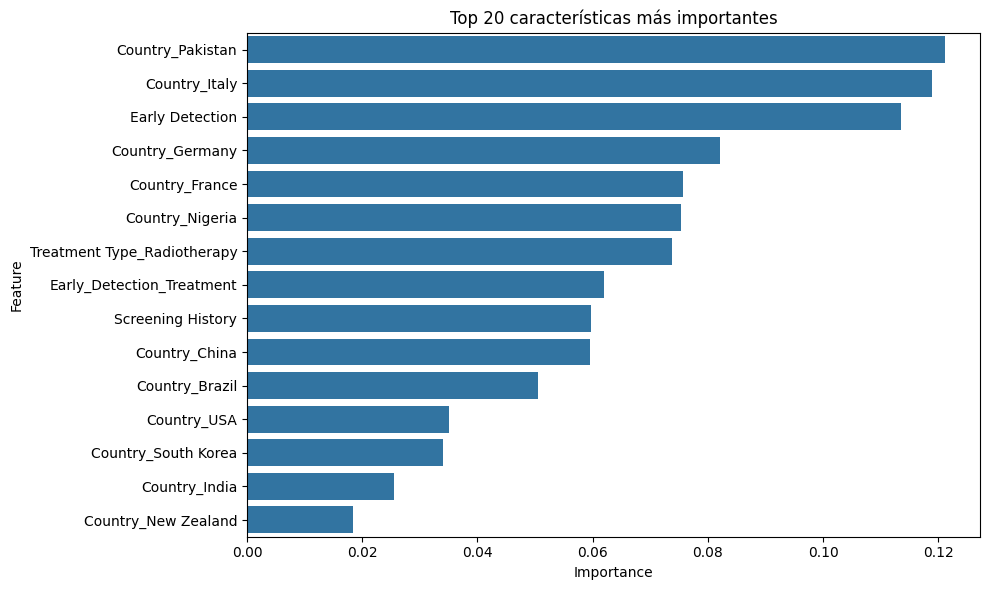

In [30]:
def objective(trial):
    # Definir el espacio de búsqueda para los hiperparámetros
    C = trial.suggest_float('C', 1e-5, 100, log=True)
    solver = trial.suggest_categorical('solver', ['saga'])
    max_iter = trial.suggest_int('max_iter', 1000, 10000, log=True)
    
    # Para los solvers que soportan regularización
    if solver in ['saga']:
        penalty = trial.suggest_categorical('penalty', ['l1', 'l2'])
        # saga es el único que soporta elasticnet
        if solver == 'saga':
            if penalty == 'elasticnet':
                l1_ratio = trial.suggest_float('l1_ratio', 0.0, 1.0)
            else:
                l1_ratio = None
        else:
            l1_ratio = None
    else:  # lbfgs solo soporta l2
        penalty = 'l2'
        l1_ratio = None
    
    # Configurar el modelo de regresión logística
    if penalty == 'elasticnet' and solver == 'saga':
        model = LogisticRegression(
            C=C, 
            penalty=penalty,
            solver=solver,
            max_iter=max_iter,
            l1_ratio=l1_ratio,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        )
    else:
        model = LogisticRegression(
            C=C, 
            penalty=penalty,
            solver=solver,
            max_iter=max_iter,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        )
    
    # Realizar validación cruzada
    cv_scores = []
    
    for train_idx, val_idx in kf.split(X_train_rfecv, y_train_processed):
        X_train_fold, X_val_fold = X_train_rfecv.iloc[train_idx], X_train_rfecv.iloc[val_idx]
        y_train_fold, y_val_fold = y_train_processed.iloc[train_idx], y_train_processed.iloc[val_idx]
        
        try:
            model.fit(X_train_fold, y_train_fold)
            y_pred = model.predict(X_val_fold)
            fold_score = f1_score(y_val_fold, y_pred, average='macro')
            cv_scores.append(fold_score)
        except Exception as e:
            # Si hay error en un fold, retornar un valor muy bajo
            print(f"Error en fold: {str(e)}")
            return float('-inf')
    
    # Calcular la media del F1 score en todos los folds
    mean_f1 = np.mean(cv_scores)
    
    # Guardar métricas adicionales como atributos del trial
    trial.set_user_attr('cv_scores', cv_scores)
    trial.set_user_attr('std_f1', np.std(cv_scores))
    
    return mean_f1

def optimize_logistic_regression():
    # Crear el objeto de estudio
    study = optuna.create_study(
        direction="maximize",
        sampler=TPESampler(seed=42),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=5)
    )
    
    # Definir callback para mostrar progreso
    def print_callback(study, trial):
        print(f"\nTrial {trial.number} completado.")
        print(f"Valor: {trial.value:.4f}")
        print(f"Parámetros: {trial.params}")
        if trial.user_attrs:
            print(f"Std F1: {trial.user_attrs.get('std_f1', 'N/A')}")
    
    # Ejecutar la optimización
    study.optimize(objective, n_trials=50, callbacks=[print_callback], show_progress_bar=True)
    
    # Mostrar los mejores resultados
    print("\n" + "="*50)
    print("MEJORES HIPERPARÁMETROS ENCONTRADOS:")
    print("="*50)
    
    best_trial = study.best_trial
    print(f"Mejor F1 Macro: {best_trial.value:.4f}")
    print(f"Desviación estándar: {best_trial.user_attrs.get('std_f1', 'N/A'):.4f}")
    print("\nHiperparámetros óptimos:")
    
    for param, value in best_trial.params.items():
        print(f"    {param}: {value}")
    
    # Crear y entrenar el modelo final con los mejores hiperparámetros
    best_params = best_trial.params.copy()
    
    # Manejar parámetros opcionales
    if 'l1_ratio' in best_params and best_params.get('penalty') != 'elasticnet':
        del best_params['l1_ratio']
    
    # Crear el modelo final
    if best_params.get('penalty') == 'elasticnet' and best_params.get('solver') == 'saga':
        best_model = LogisticRegression(
            **best_params,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        )
    else:
        # Eliminar l1_ratio si existe y no es necesario
        if 'l1_ratio' in best_params:
            del best_params['l1_ratio']
        best_model = LogisticRegression(
            **best_params,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        )
    
    # Entrenar con todo el conjunto de entrenamiento
    best_model.fit(X_train_rfecv, y_train_processed)
    
    # Evaluar en el conjunto de validación
    y_pred = best_model.predict(X_val_rfecv)
    val_f1 = f1_score(y_val_processed, y_pred, average='macro')
    
    print("\nRendimiento en el conjunto de validación:")
    print(f"F1 Macro: {val_f1:.4f}")
    
    # Visualizar la importancia de las características
    if hasattr(best_model, 'coef_'):
        # Ensure the number of features matches the coefficients
        if len(X_train_rfecv.columns) == len(best_model.coef_[0]):
            feature_importance = pd.DataFrame({
                'Feature': X_train_rfecv.columns,
                'Importance': np.abs(best_model.coef_[0])
            }).sort_values('Importance', ascending=False)
        else:
            print("Warning: Mismatch between feature names and model coefficients.")
            feature_importance = pd.DataFrame({
                'Feature': X_train_rfecv.columns[:len(best_model.coef_[0])],
                'Importance': np.abs(best_model.coef_[0])
            }).sort_values('Importance', ascending=False)
        
        plt.figure(figsize=(10, 6))
        sns.barplot(x='Importance', y='Feature', data=feature_importance.head(20))
        plt.title('Top 20 características más importantes')
        plt.tight_layout()
        plt.show()
    
    return best_model, study

# Ejecutar la optimización
best_lr_model, lr_study = optimize_logistic_regression()

[I 2025-05-10 21:37:34,812] A new study created in memory with name: no-name-64182413-4907-47b1-988d-6a14c782decf


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-05-10 21:37:50,559] Trial 0 finished with value: 0.5011987551971891 and parameters: {'n_estimators': 218, 'max_depth': 29, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 0 with value: 0.5011987551971891.

Trial 0 completado.
Valor original: 0.5012
Valor ajustado: 0.5012
Parámetros: {'n_estimators': 218, 'max_depth': 29, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'bootstrap': True}
Std F1: 0.0022161413428816077
Sobreajuste: 0.0177
[I 2025-05-10 21:38:04,394] Trial 1 finished with value: 0.5000353075385325 and parameters: {'n_estimators': 369, 'max_depth': 5, 'min_samples_split': 20, 'min_samples_leaf': 9, 'max_features': 'sqrt', 'bootstrap': False}. Best is trial 0 with value: 0.5011987551971891.

Trial 1 completado.
Valor original: 0.5000
Valor ajustado: 0.5000
Parámetros: {'n_estimators': 369, 'max_depth': 5, 'min_samples_split': 20, 'min_samples_leaf': 9, 'max_features': 'sqrt', 'bootstrap

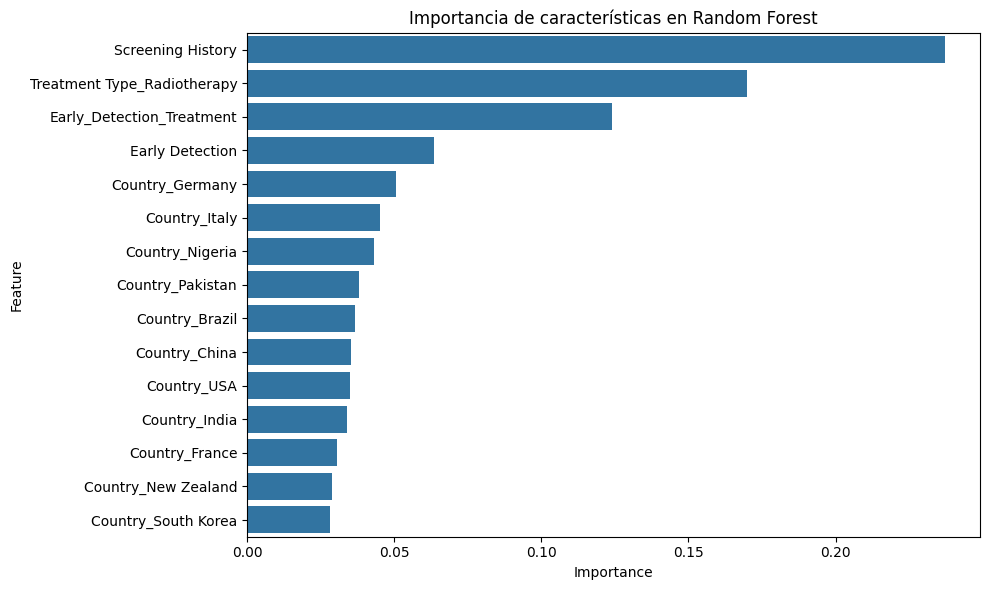

In [31]:
def rf_objective(trial):
    # Definir el espacio de búsqueda para los hiperparámetros
    n_estimators = trial.suggest_int('n_estimators', 50, 500)
    max_depth = trial.suggest_int('max_depth', 5, 30)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
    bootstrap = trial.suggest_categorical('bootstrap', [True, False])
    
    # Configurar el modelo RandomForest
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        bootstrap=bootstrap,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
    
    # Realizar validación cruzada
    cv_scores = []
    
    for train_idx, val_idx in kf.split(X_train_rfecv, y_train_processed):
        X_train_fold, X_val_fold = X_train_rfecv.iloc[train_idx], X_train_rfecv.iloc[val_idx]
        y_train_fold, y_val_fold = y_train_processed.iloc[train_idx], y_train_processed.iloc[val_idx]
        
        try:
            model.fit(X_train_fold, y_train_fold)
            
            # Calcular predicciones y F1 score
            y_pred = model.predict(X_val_fold)
            fold_score = f1_score(y_val_fold, y_pred, average='macro')
            
            # Calcular overfitting: diferencia entre train y val
            y_train_pred = model.predict(X_train_fold)
            train_score = f1_score(y_train_fold, y_train_pred, average='macro')
            overfit = train_score - fold_score
            
            cv_scores.append(fold_score)
            
            # Almacenar métricas adicionales
            trial.set_user_attr(f'train_f1_fold_{len(cv_scores)}', train_score)
            trial.set_user_attr(f'val_f1_fold_{len(cv_scores)}', fold_score)
            trial.set_user_attr(f'overfit_fold_{len(cv_scores)}', overfit)
            
        except Exception as e:
            # Si hay error en un fold, retornar un valor muy bajo
            print(f"Error en fold: {str(e)}")
            return float('-inf')
    
    # Calcular la media del F1 score en todos los folds
    mean_f1 = np.mean(cv_scores)
    
    # Calcular métricas agregadas
    train_scores = [trial.user_attrs[f'train_f1_fold_{i+1}'] for i in range(len(cv_scores))]
    val_scores = [trial.user_attrs[f'val_f1_fold_{i+1}'] for i in range(len(cv_scores))]
    overfit_scores = [trial.user_attrs[f'overfit_fold_{i+1}'] for i in range(len(cv_scores))]
    
    # Guardar métricas adicionales como atributos del trial
    trial.set_user_attr('cv_scores', cv_scores)
    trial.set_user_attr('std_f1', np.std(cv_scores))
    trial.set_user_attr('mean_train_f1', np.mean(train_scores))
    trial.set_user_attr('mean_overfit', np.mean(overfit_scores))
    
    # Penalización por sobreajuste para guiar la búsqueda hacia modelos más generalizables
    if np.mean(overfit_scores) > 0.1:  # Si hay sobreajuste significativo
        penalty = (np.mean(overfit_scores) - 0.1) * 0.5  # Penalización proporcional al exceso de sobreajuste
        adjusted_score = mean_f1 - penalty
    else:
        adjusted_score = mean_f1
    
    trial.set_user_attr('adjusted_score', adjusted_score)
    
    return adjusted_score  # Retornamos el score ajustado para guiar la optimización

def optimize_random_forest():
    # Crear el objeto de estudio
    study = optuna.create_study(
        direction="maximize",
        sampler=TPESampler(seed=42),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=5)
    )
    
    # Definir callback para mostrar progreso
    def print_callback(study, trial):
        print(f"\nTrial {trial.number} completado.")
        print(f"Valor original: {np.mean(trial.user_attrs.get('cv_scores', [0])):.4f}")
        print(f"Valor ajustado: {trial.value:.4f}")
        print(f"Parámetros: {trial.params}")
        print(f"Std F1: {trial.user_attrs.get('std_f1', 'N/A')}")
        print(f"Sobreajuste: {trial.user_attrs.get('mean_overfit', 'N/A'):.4f}")
    
    # Ejecutar la optimización
    study.optimize(rf_objective, n_trials=50, callbacks=[print_callback], show_progress_bar=True)
    
    # Mostrar los mejores resultados
    print("\n" + "="*50)
    print("MEJORES HIPERPARÁMETROS ENCONTRADOS PARA RANDOM FOREST:")
    print("="*50)
    
    best_trial = study.best_trial
    print(f"Mejor F1 Macro ajustado: {best_trial.value:.4f}")
    print(f"Mejor F1 Macro original: {np.mean(best_trial.user_attrs.get('cv_scores', [0])):.4f}")
    print(f"Desviación estándar: {best_trial.user_attrs.get('std_f1', 'N/A'):.4f}")
    print(f"Sobreajuste: {best_trial.user_attrs.get('mean_overfit', 'N/A'):.4f}")
    print("\nHiperparámetros óptimos:")
    
    for param, value in best_trial.params.items():
        print(f"    {param}: {value}")
    
    # Crear y entrenar el modelo final con los mejores hiperparámetros
    best_params = best_trial.params.copy()
    best_model = RandomForestClassifier(
        **best_params,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
    
    # Entrenar con todo el conjunto de entrenamiento
    best_model.fit(X_train_rfecv, y_train_processed)
    
    # Evaluar en el conjunto de validación
    y_pred = best_model.predict(X_val_rfecv)
    val_f1 = f1_score(y_val_processed, y_pred, average='macro')
    
    print("\nRendimiento en el conjunto de validación:")
    print(f"F1 Macro: {val_f1:.4f}")
    
    # Visualizar la importancia de las características
    feature_importance = pd.DataFrame({
        'Feature': X_train_rfecv.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_importance)
    plt.title('Importancia de características en Random Forest')
    plt.tight_layout()
    plt.show()
    
    return best_model, study

# Ejecutar la optimización
best_rf_model, rf_study = optimize_random_forest()